# Bank Customer Churn Prediction
In this kernel I am going to make an __Exploratory Data Analysis (EDA)__ on [this](https://www.kaggle.com/filippoo/deep-learning-az-ann) dataset. Also I am going to make different predictive models and find out the best one with highest prediction accuracy. 

### Kernel Outlines:
* __Introduction & Problem Statement__ 
Customer churn is a critical issue in the banking sector. This project aims to predict whether a customer will leave the bank using machine learning techniques.
* __Importing Necessary Packages__
* __Data Cleaning and Preparation__
* __Statistical Summary of the Dataset__
* __Dropping Irrelevant Features__
* __Data Visualization__
* __Encoding Categorical Features__
* __Checking Correlation with Heatmap__
* __Detecting Outliers using Tukey Boxplot__
* __Hand written function for detecting and removing outliers__
* __Target__
Exited → 1 (churn), 0 (stay)
* __Train Supervised Classification Models__
    * Gaussian Naive Bayes
    * Logistic Regression
    * Decision Tree
    * Random Forest
    * Extra Gradient Boosting Tree (XGBoost)
* __Feature Importance Analysis__
* __Feature Importance Analysis__
    * Feature Scaling
    * Over Sampling

In [1]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install imblearn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importing Necessary Packages

In [3]:
#  Basic Libraries
import numpy as np
import pandas as pd

#  Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(palette="Set2")

#  Sklearn - Model & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    precision_score, recall_score, roc_auc_score
)

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree

#  Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

#  Advanced Models
from xgboost import XGBClassifier, plot_importance

#  Handling Imbalance
from imblearn.over_sampling import SMOTE

#  Confusion Matrix Plot
from mlxtend.plotting import plot_confusion_matrix

In [4]:
# read dataset
dataset = pd.read_csv("Customer-churn-records.csv")

In [5]:
# first five row of the dataset
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


### __The statistical summary of the dataset__

In [6]:
dataset.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [7]:
# checking datatypes and null values
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

### Dropping Irrelevant Feature
`RowNumber`, `CustomerId` and `Surname` are irrelivant, so we drop those features.

In [8]:
dataset.drop(["RowNumber","CustomerId","Surname"], axis=1, inplace=True)

## Data Visualization 

<Axes: xlabel='IsActiveMember', ylabel='count'>

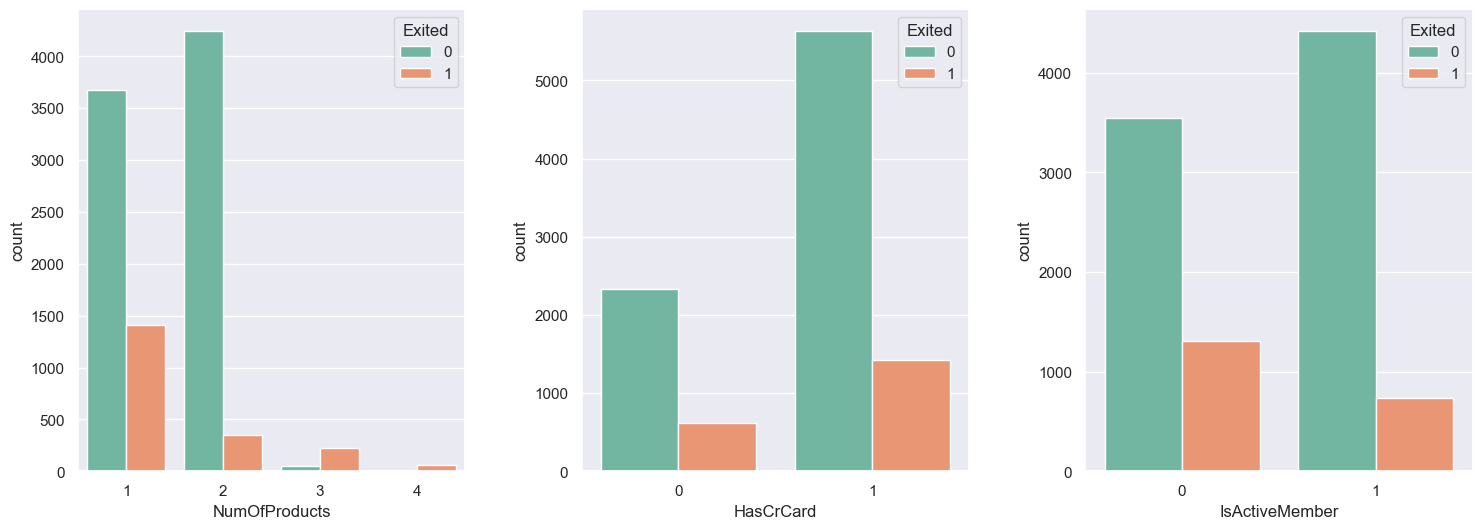

In [9]:
_, ax = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(wspace=0.3)
sns.countplot(x = "NumOfProducts", hue="Exited", data = dataset, ax= ax[0])
sns.countplot(x = "HasCrCard", hue="Exited", data = dataset, ax = ax[1])
sns.countplot(x = "IsActiveMember", hue="Exited", data = dataset, ax = ax[2])

__Customer with 3 or 4 products are higher chances to Churn__

C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 92.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 91.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 14.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 93.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\pds\AppData\Roaming\Python\

<Axes: xlabel='IsActiveMember', ylabel='Age'>

C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 88.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 86.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


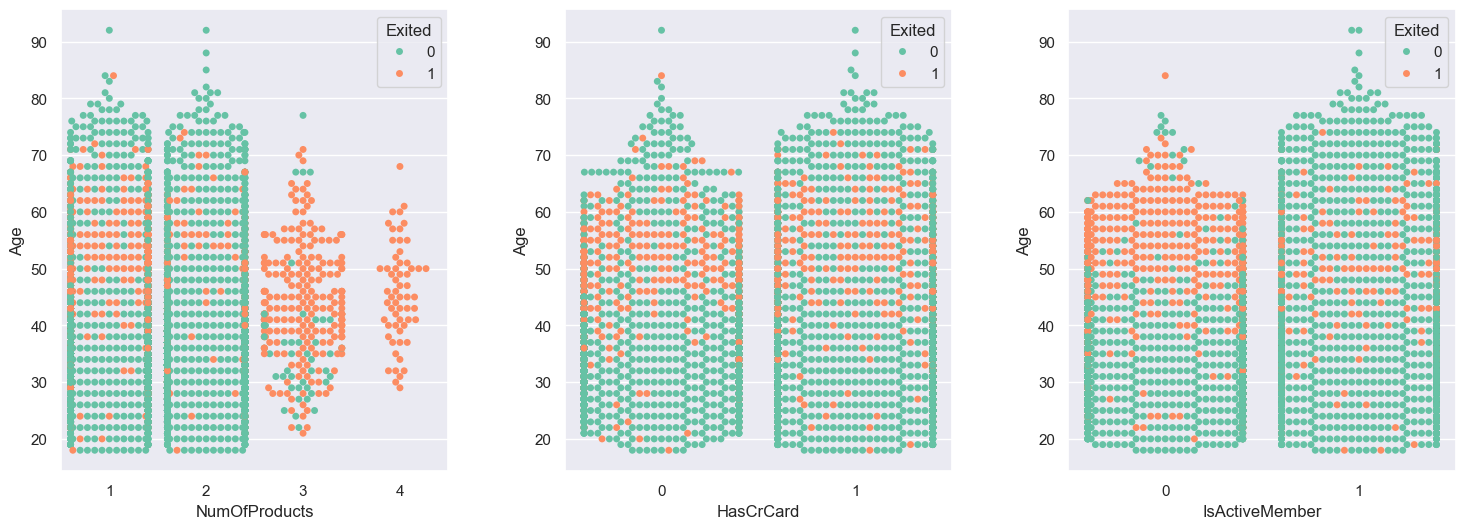

In [10]:
_, ax = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(wspace=0.3)
sns.swarmplot(x = "NumOfProducts", y = "Age", hue="Exited", data = dataset, ax= ax[0])
sns.swarmplot(x = "HasCrCard", y = "Age", data = dataset, hue="Exited", ax = ax[1])
sns.swarmplot(x = "IsActiveMember", y = "Age", hue="Exited", data = dataset, ax = ax[2])

In [11]:
encoder = LabelEncoder()
dataset["Geography"] = encoder.fit_transform(dataset["Geography"])
dataset["Gender"] = encoder.fit_transform(dataset["Gender"])

<Axes: xlabel='Age'>

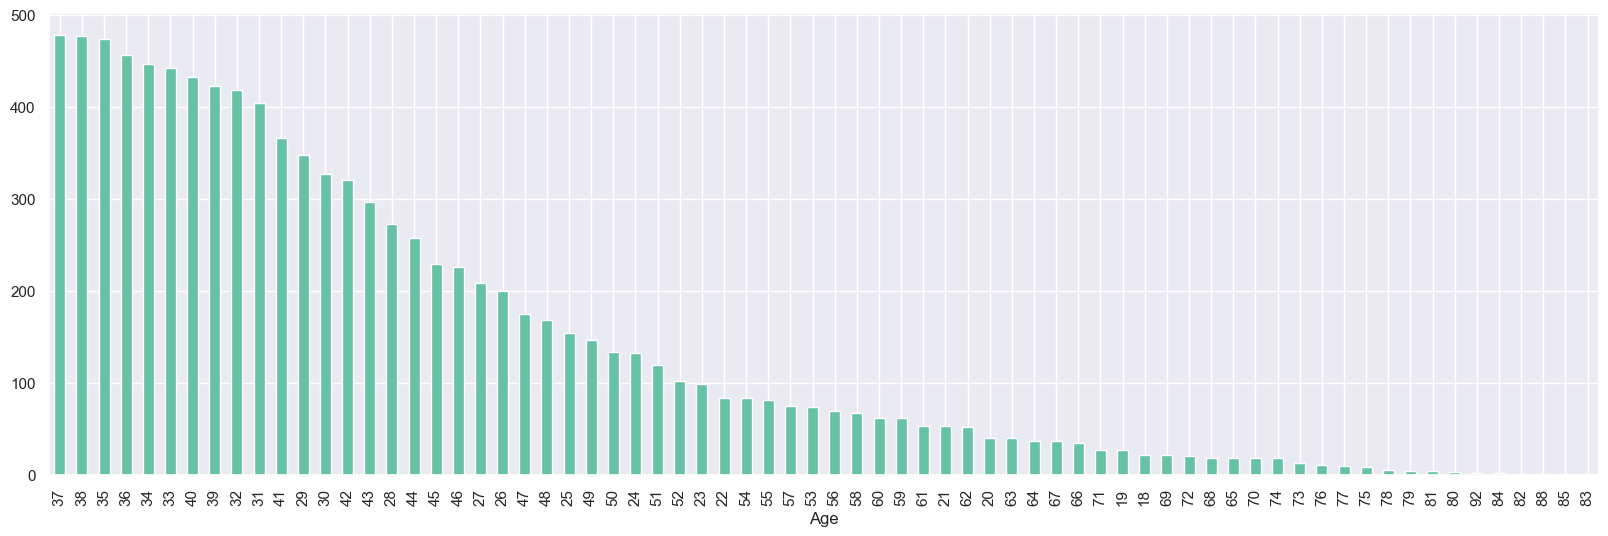

In [12]:
dataset["Age"].value_counts().plot.bar(figsize=(20,6))

C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


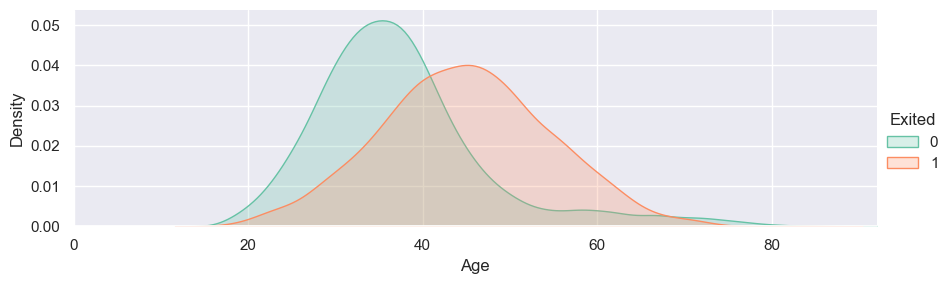

In [13]:
facet = sns.FacetGrid(dataset, hue="Exited",aspect=3)
facet.map(sns.kdeplot,"Age",shade= True)
facet.set(xlim=(0, dataset["Age"].max()))
facet.add_legend()

plt.show()

C:\Users\pds\AppData\Local\Temp\ipykernel_14532\982642712.py:5: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.scatterplot(
C:\Users\pds\AppData\Local\Temp\ipykernel_14532\982642712.py:14: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.scatterplot(


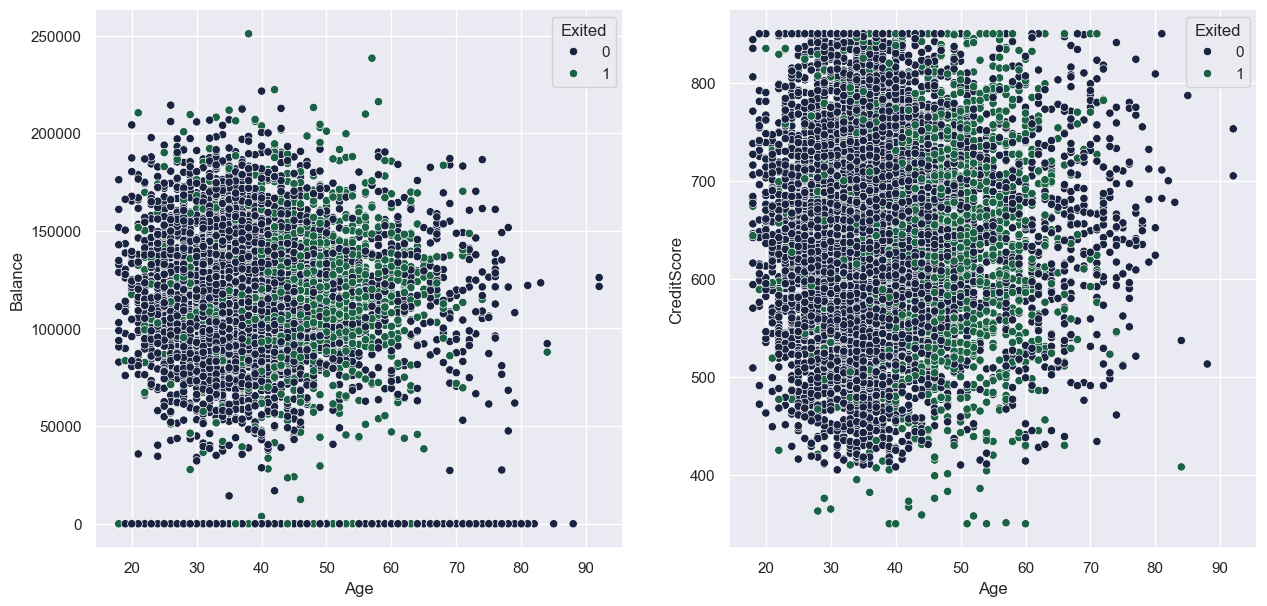

In [15]:
_, ax = plt.subplots(1, 2, figsize=(15, 7))

palette = sns.color_palette("cubehelix", as_cmap=False)

sns.scatterplot(
    x="Age",
    y="Balance",
    hue="Exited",
    palette=palette,
    data=dataset,
    ax=ax[0]
)

sns.scatterplot(
    x="Age",
    y="CreditScore",
    hue="Exited",
    palette=palette,
    data=dataset,
    ax=ax[1]
)

plt.show()

> * __40 to 70 years old customers are higher chances to churn__
* __Customer with `CreditScore` less then `400` are higher chances to churn__

C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 30.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 61.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='HasCrCard', ylabel='Age'>

C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 51.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 74.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


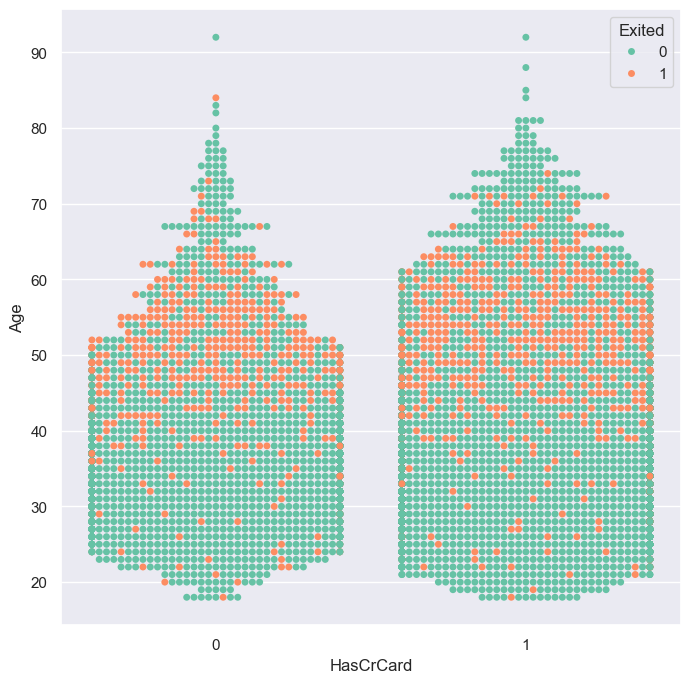

In [16]:
plt.figure(figsize=(8, 8))
sns.swarmplot(x = "HasCrCard", y = "Age", data = dataset, hue="Exited")

C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


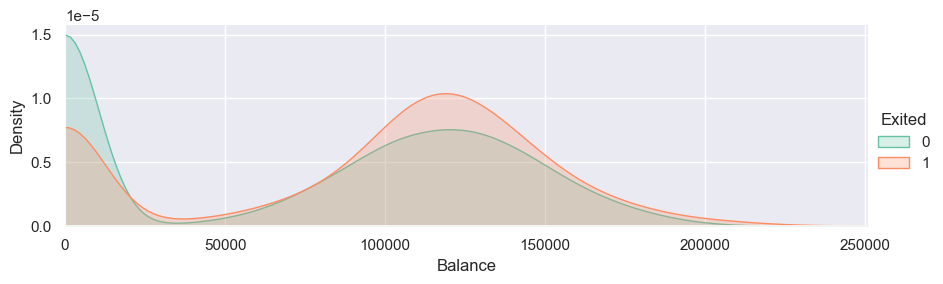

In [17]:
facet = sns.FacetGrid(dataset, hue="Exited",aspect=3)
facet.map(sns.kdeplot,"Balance",shade= True)
facet.set(xlim=(0, dataset["Balance"].max()))
facet.add_legend()

plt.show()

<Axes: xlabel='Balance', ylabel='CreditScore'>

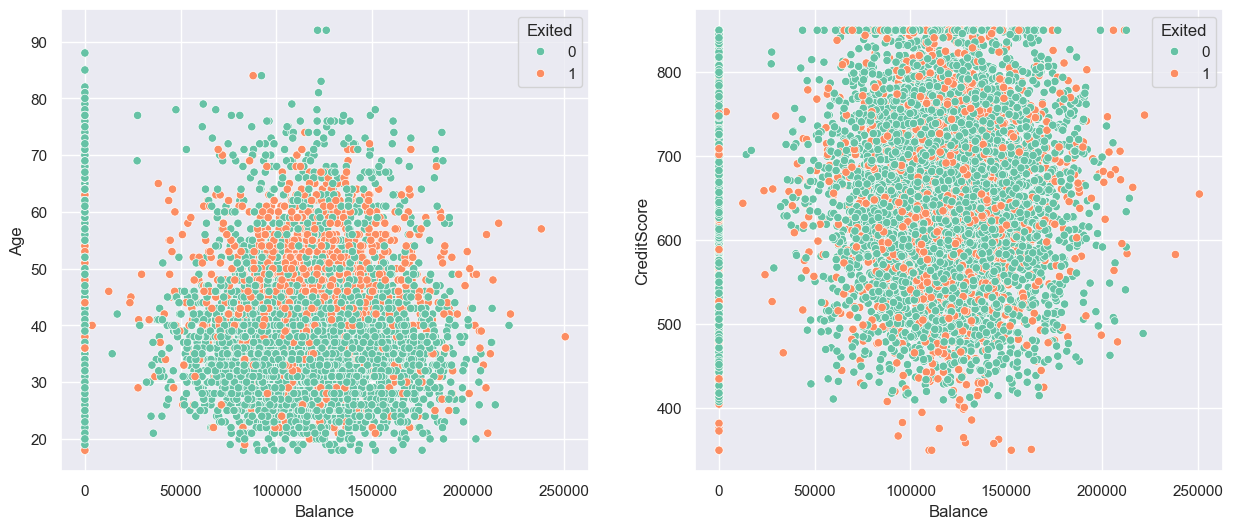

In [18]:
_, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x = "Balance", y = "Age", data = dataset, hue="Exited", ax = ax[0])
sns.scatterplot(x = "Balance", y = "CreditScore", data = dataset, hue="Exited", ax = ax[1])

C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


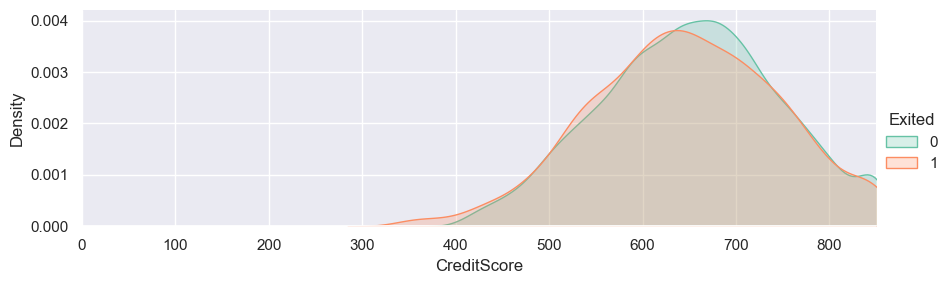

In [19]:
facet = sns.FacetGrid(dataset, hue="Exited",aspect=3)
facet.map(sns.kdeplot,"CreditScore",shade= True)
facet.set(xlim=(0, dataset["CreditScore"].max()))
facet.add_legend()

plt.show()

### __Detecting Outliers using Tukey Boxplot__

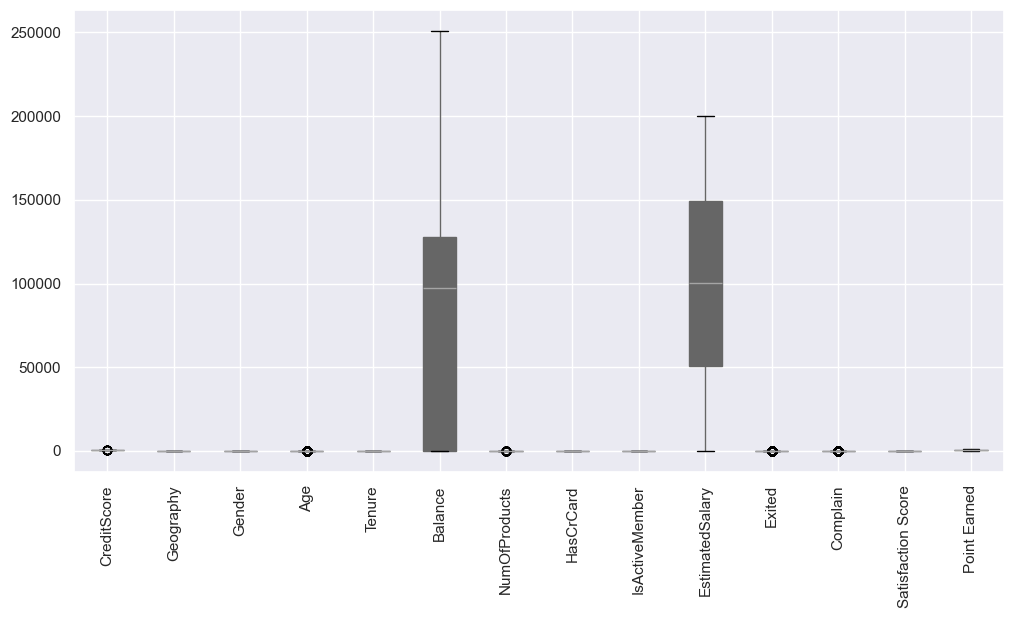

In [20]:
plt.figure(figsize=(12,6))
bplot = dataset.boxplot(patch_artist=True)
plt.xticks(rotation=90)       
plt.show()

### __Checking Correlation Heatmap__

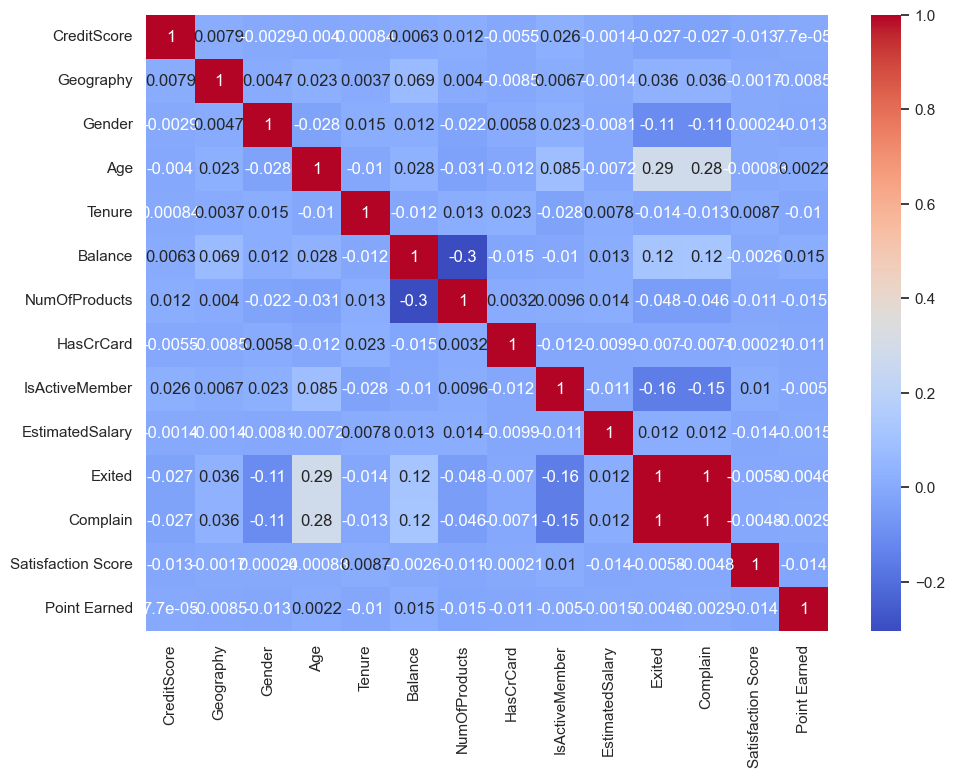

In [22]:
plt.subplots(figsize=(11,8))

# Select only numeric columns
numeric_data = dataset.select_dtypes(include=['number'])

# Heatmap
sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## Target:

In [52]:
dataset = pd.get_dummies(dataset, drop_first=True)

In [53]:
X = dataset.drop("Exited", axis=1)
y = dataset["Exited"]

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


## Train Supervised Classification Models:

In [33]:

# Model
clf = GaussianNB()

# Train
clf.fit(X_train, y_train)

# Prediction
pred = clf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.801


In [34]:
print(X.select_dtypes(include="object").columns)

Index([], dtype='object')


In [35]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
accuracy_score(pred, y_test)

C:\Users\pds\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.794

In [36]:
clf = tree.DecisionTreeClassifier()
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
accuracy_score(pred, y_test)

0.9975

In [37]:
clf = RandomForestClassifier(n_estimators = 200, random_state=200)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
accuracy_score(pred, y_test)

0.999

In [38]:
clf  = XGBClassifier(max_depth = 10,random_state = 10, n_estimators=220, eval_metric = 'auc', min_child_weight = 3,
                    colsample_bytree = 0.75, subsample= 0.9)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)
accuracy_score(pred, y_test)

0.999

## Feature Scaling

In [40]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Initialize scaler
scaler = MinMaxScaler()

# Columns to scale
bumpy_features = [
    "CreditScore",
    "Age",
    "Balance",
    "EstimatedSalary"
]

# Copy dataset
df_scaled = X.copy()

# Apply scaling
df_scaled[bumpy_features] = scaler.fit_transform(
    X[bumpy_features]
)

# View result
df_scaled.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Point Earned,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,0.538,0,0,0.324324,2,0.000000,1,1,1,0.506735,1,2,464,False,False,False
1,0.516,2,0,0.310811,1,0.334031,1,0,1,0.562709,1,3,456,False,False,False
2,0.304,0,0,0.324324,8,0.636357,3,1,0,0.569654,1,3,377,False,False,False
3,0.698,0,0,0.283784,1,0.000000,2,0,0,0.469120,0,5,350,True,False,False
4,1.000,2,0,0.337838,2,0.500246,1,1,1,0.395400,0,5,425,True,False,False


In [41]:
df_scaled.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Point Earned,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,0.538,0,0,0.324324,2,0.000000,1,1,1,0.506735,1,2,464,False,False,False
1,0.516,2,0,0.310811,1,0.334031,1,0,1,0.562709,1,3,456,False,False,False
2,0.304,0,0,0.324324,8,0.636357,3,1,0,0.569654,1,3,377,False,False,False
3,0.698,0,0,0.283784,1,0.000000,2,0,0,0.469120,0,5,350,True,False,False
4,1.000,2,0,0.337838,2,0.500246,1,1,1,0.395400,0,5,425,True,False,False


### Over Sampling

In [43]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df_scaled

# Apply SMOTE
sm = SMOTE(random_state=42)

X_res, y_res = sm.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res,
    y_res,
    test_size=0.2,
    random_state=7
)

In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

clf = XGBClassifier(
    max_depth=12,
    random_state=7,
    n_estimators=100,
    eval_metric='auc',
    min_child_weight=3,
    colsample_bytree=0.75,
    subsample=0.8
)

clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Average Precision (AUC-PR):", average_precision_score(y_test, y_proba))

Accuracy: 0.9968602825745683
Precision: 0.9968730456535334
Recall: 0.9968730456535334
F1: 0.9968730456535334
Average Precision (AUC-PR): 0.9997915967696499


In [46]:
# Confusion Matrix
confusion_matrix(y_test, y_pred)

array([[1581,    5],
       [   5, 1594]])

In [56]:
import joblib

joblib.dump(clf, "model.pkl")

joblib.dump(X.columns, "features.pkl")

['features.pkl']